# Physics–Habitability Relations Explorer

This notebook focuses on *interpreting* how underlying astrophysical and planetary physics parameters relate to downstream **habitability scores** and **classification outcomes** produced in the modeling workflow.

Goals:
1. Load curated planet dataset with physics-derived features.
2. Derive interpretable secondary metrics (ratios, normalized forms).
3. Visualize pairwise and multivariate relationships.
4. Explain each graph in plain language (no advanced math needed).
5. Export figures for inclusion into a dedicated LaTeX report.
6. Produce a LaTeX document summarizing insights.

Output figures are saved to: `docs/images/relations/`.
The generated LaTeX file: `docs/latex/physics_relations_report.tex`.

In [71]:
# Imports and configuration
import os, json, math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Plot style
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

# Output directory for figures
REL_IMG_DIR = Path('docs/images/relations')
REL_IMG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str, tight=True):
    path = REL_IMG_DIR / f'{name}.png'
    if tight: plt.tight_layout()
    plt.savefig(path, dpi=160)
    print(f'[saved] {path}')

print('Environment ready.')

Environment ready.


## 1. Load Data
We attempt to load the cleaned NASA exoplanet dataset that already includes engineered physics features.
Fallback order (first existing file wins):
- `data_science/datasets/nasa_clean.csv`
- `data_science/datasets/nasa_exoplanets.csv`
- `data_science/datasets/sample_planets.csv` (demo subset)
If none are found, we generate a small synthetic sample for illustration.

In [72]:
candidate_paths = [
    Path('data_science/datasets/nasa_clean.csv'),
    Path('data_science/datasets/nasa_exoplanets.csv'),
    Path('data_science/datasets/sample_planets.csv'),
]
data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    print('No real dataset found, creating synthetic demo data...')
    rng = np.random.default_rng(42)
    n = 120
    df = pd.DataFrame({
        'planet_name': [f'Planet_{i}' for i in range(n)],
        'stellar_temp': rng.normal(5500, 800, n),
        'stellar_radius': rng.normal(1.0, 0.2, n),
        'semi_major_axis': rng.lognormal(mean=-0.2, sigma=0.6, size=n),
        'planet_radius': rng.normal(1.1, 0.4, n).clip(0.3),
        'planet_mass': rng.normal(1.3, 0.7, n).clip(0.1),
        'equilibrium_temp': rng.normal(270, 60, n),
        'escape_velocity_ratio': rng.normal(1.0, 0.3, n).clip(0.2),
        'tidal_lock_likelihood': rng.uniform(0, 1, n),
        'habitable_zone_flag': rng.integers(0,2,n),
        'earth_similarity_index': rng.uniform(0.2, 0.95, n),
        'habitability_score': rng.uniform(0,1,n)
    })
    # Binary classification label (demo threshold)
    df['is_habitable'] = (df['habitability_score'] > 0.55).astype(int)
else:
    print(f'Loaded dataset: {data_path}')
    df = pd.read_csv(data_path)
    # attempt to infer labels if missing
    if 'is_habitable' not in df.columns and 'habitability_score' in df.columns:
        df['is_habitable'] = (df['habitability_score'] > df['habitability_score'].median()).astype(int)

print(f'Dataset shape: {df.shape}')
df.head()

No real dataset found, creating synthetic demo data...
Dataset shape: (120, 13)


,planet_name,stellar_temp,stellar_radius,semi_major_axis,planet_radius,planet_mass,equilibrium_temp,escape_velocity_ratio,tidal_lock_likelihood,habitable_zone_flag,earth_similarity_index,habitability_score,is_habitable
0,Planet_0,5743.773664,0.795301,0.483784,1.038991,1.456156,300.924624,0.971146,0.979225,1,0.406364,0.257452,0
1,Planet_1,4668.012715,1.035855,0.773710,1.253358,2.303250,235.347667,1.338406,0.377145,1,0.303991,0.752329,1
2,Planet_2,6100.360957,1.043999,0.285179,1.499930,1.364064,346.466833,0.315779,0.719313,1,0.412641,0.504179,0
3,Planet_3,6252.451773,1.271838,0.339518,0.676586,1.706544,232.344748,0.551008,0.887571,0,0.706052,0.750266,1
4,Planet_4,3939.171849,1.167022,2.937469,1.049996,1.260252,231.803083,0.723134,0.394630,0,0.882745,0.464680,0


## 2. Feature Selection for Relation Study
We pick a curated subset of physically interpretable features and derive extra normalized versions for ratio-based comparisons.

In [73]:
base_features = [
    'stellar_temp','stellar_radius','semi_major_axis','planet_radius','planet_mass',
    'equilibrium_temp','escape_velocity_ratio','tidal_lock_likelihood',
    'earth_similarity_index','habitability_score','is_habitable'
]
available = [c for c in base_features if c in df.columns]
print('Using features:', available)
sub = df[available].copy()

# Derived relations (guard with try/except for robustness)
def safe_div(a,b):
    with np.errstate(divide='ignore', invalid='ignore'):
        r = np.where(b==0, np.nan, a/b)
    return r

if 'equilibrium_temp' in sub and 'stellar_temp' in sub:
    sub['temp_ratio'] = safe_div(sub['equilibrium_temp'], sub['stellar_temp'])
if 'planet_mass' in sub and 'planet_radius' in sub:
    sub['mass_radius_ratio'] = safe_div(sub['planet_mass'], sub['planet_radius'])
if 'semi_major_axis' in sub and 'stellar_radius' in sub:
    sub['a_over_rstar'] = safe_div(sub['semi_major_axis'], sub['stellar_radius'])

print('Derived columns added:', [c for c in sub.columns if c not in available][:10], '...')
sub.describe(include='all').T.head(15)

Using features: ['stellar_temp', 'stellar_radius', 'semi_major_axis', 'planet_radius', 'planet_mass', 'equilibrium_temp', 'escape_velocity_ratio', 'tidal_lock_likelihood', 'earth_similarity_index', 'habitability_score', 'is_habitable']
Derived columns added: ['temp_ratio', 'mass_radius_ratio', 'a_over_rstar'] ...


,count,mean,std,min,25%,50%,75%,max
stellar_temp,120.0,5451.678489,627.910464,3939.171849,5063.474383,5473.309173,5904.758284,7213.318081
stellar_radius,120.0,0.993277,0.201272,0.570542,0.836990,0.970470,1.093817,1.582772
semi_major_axis,120.0,1.026759,0.682451,0.175521,0.579508,0.876052,1.273148,4.678794
planet_radius,120.0,1.097741,0.401313,0.300000,0.826053,1.113156,1.355947,2.139069
planet_mass,120.0,1.253939,0.677685,0.100000,0.742463,1.245127,1.693816,2.994291
equilibrium_temp,120.0,262.356926,60.410944,116.115339,221.302474,258.269145,302.729157,422.959677
escape_velocity_ratio,120.0,1.002457,0.306840,0.200000,0.775661,1.015373,1.224052,1.614627
tidal_lock_likelihood,120.0,0.498582,0.290121,0.030055,0.247620,0.468588,0.761212,0.988604
earth_similarity_index,120.0,0.593802,0.223288,0.200389,0.400570,0.602293,0.798860,0.949566
habitability_score,120.0,0.473502,0.283278,0.001067,0.213639,0.449888,0.687278,0.996677


## 3. Simple Distributions
We start with single-variable (univariate) distributions to understand basic ranges and skewness.
Plain explanation: These histograms show how common or rare different values are.

[saved] docs\images\relations\01_feature_distributions.png


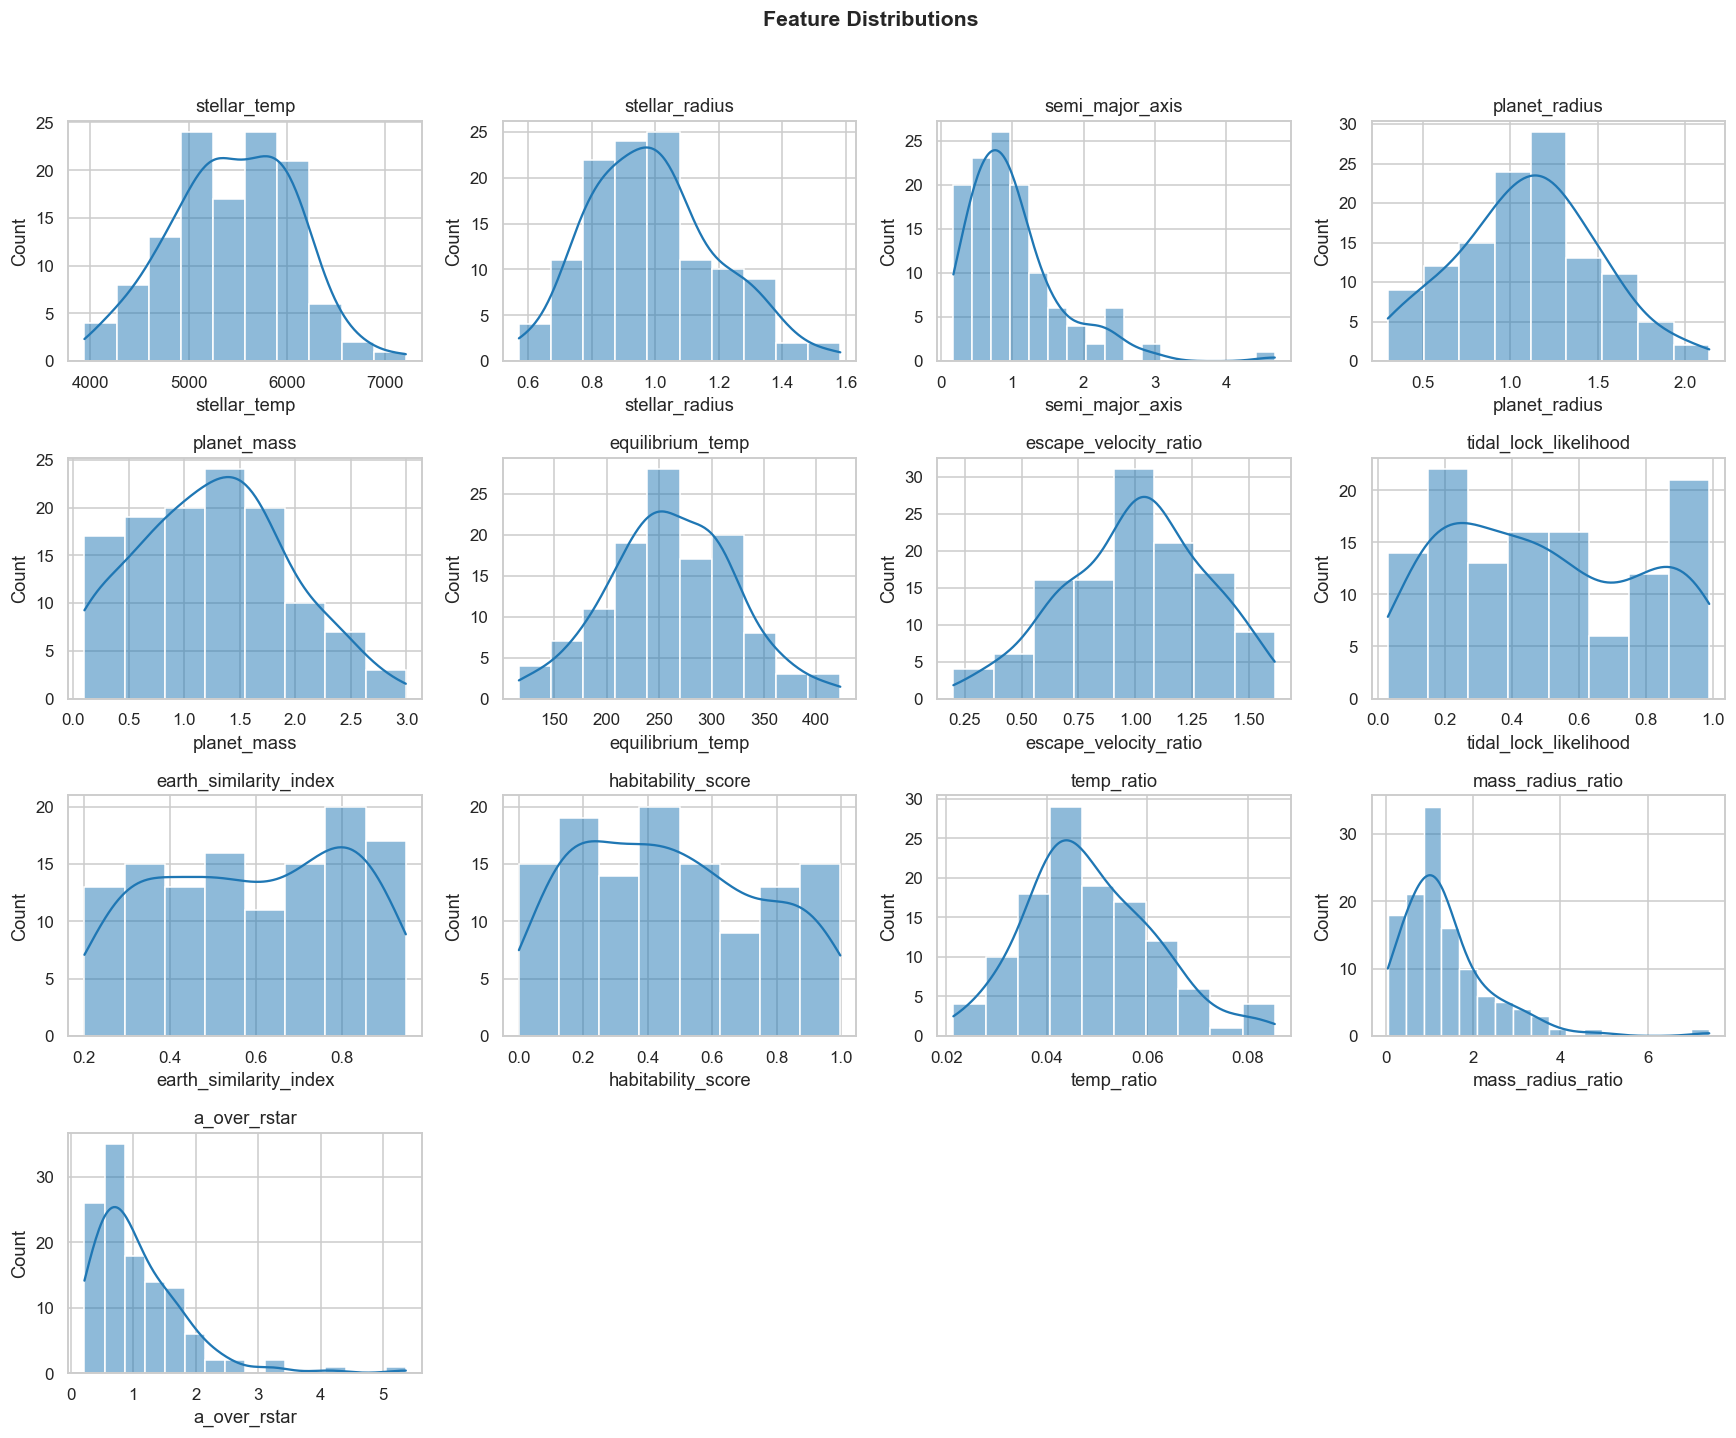

In [74]:
numeric_cols = [c for c in sub.columns if sub[c].dtype != 'O' and c not in ['is_habitable']]
n = len(numeric_cols)
cols = 4
rows = math.ceil(n/cols)
plt.figure(figsize=(4*cols, 3.2*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(sub[col].dropna(), kde=True, color='#1f77b4')
    plt.title(col)
plt.suptitle('Feature Distributions', y=1.02, fontsize=14, fontweight='bold')
savefig('01_feature_distributions')
plt.show()

**Interpretation:**
- A tall narrow peak means most planets cluster around that value.
- A long tail means a few extreme planets stretch the scale.
- KDE (smooth curve) helps see the overall shape without bin artifacts.

## 4. Correlation Matrix (Physics vs Habitability)
We inspect linear correlations (Pearson) to see which physics features co-vary with the habitability score.
Simpler description: *If two features rise and fall together, their correlation is positive; if one rises while the other falls, it's negative.*

[saved] docs\images\relations\02_correlation_matrix.png


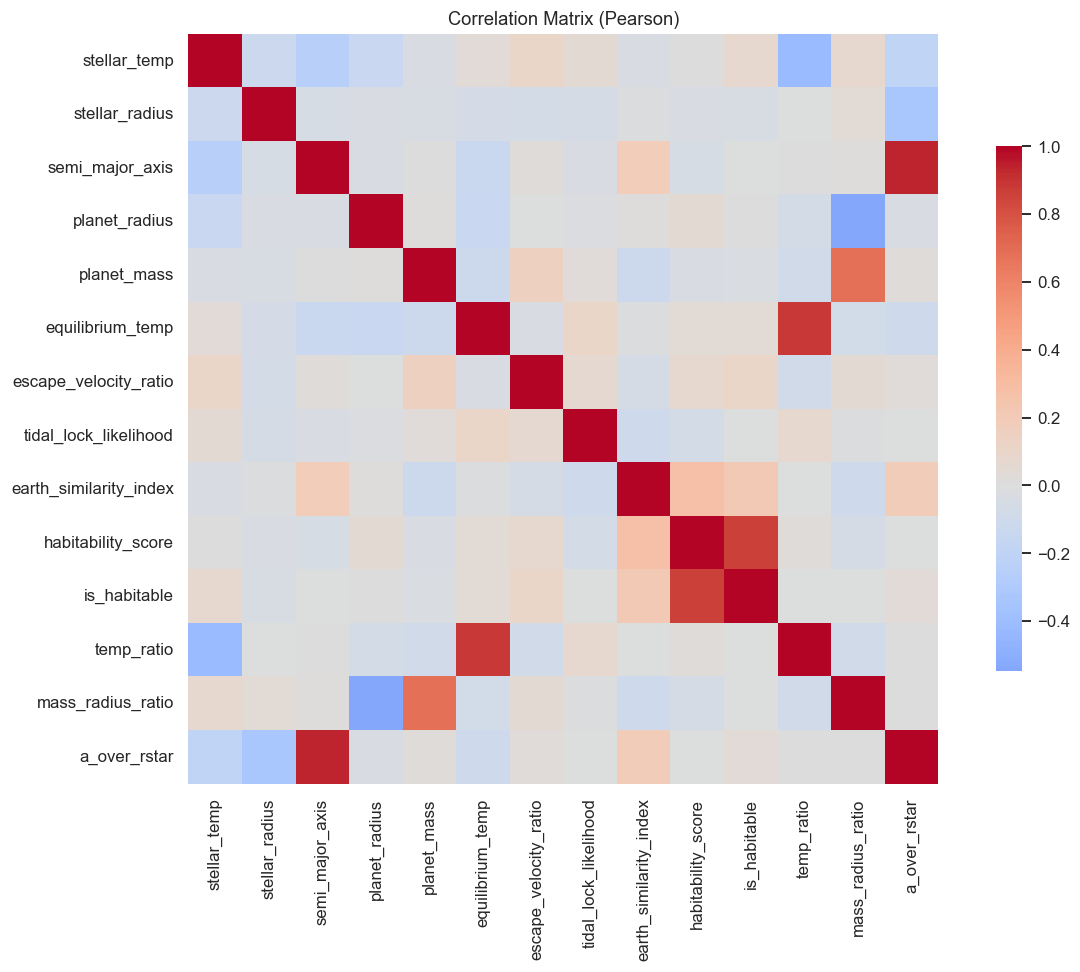

habitability_score        1.000000
is_habitable              0.858388
earth_similarity_index    0.278088
escape_velocity_ratio     0.076367
planet_radius             0.054288
equilibrium_temp          0.041231
temp_ratio                0.022021
stellar_temp              0.006332
a_over_rstar             -0.007273
stellar_radius           -0.033193
planet_mass              -0.037842
semi_major_axis          -0.051723
Name: habitability_score, dtype: float64

In [75]:
corr_cols = [c for c in sub.columns if sub[c].dtype != 'O']
corr = sub[corr_cols].corr(method='pearson')
plt.figure(figsize=(12,9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True, cbar_kws={'shrink':0.7})
plt.title('Correlation Matrix (Pearson)')
savefig('02_correlation_matrix')
plt.show()
corr['habitability_score'].sort_values(ascending=False).head(12)

**Interpretation:** Warm (red) squares: both features increase together. Cool (blue) squares: one increases while the other decreases. Near white: weak linear relationship. Correlation does **not** prove cause—just co-movement.

## 5. Pairwise Physics vs Habitability Scatter Grid
Shows how the habitability score changes with key physics drivers, one plot per feature. A color hue marks the binary classification label where available.

[saved] docs\images\relations\03_physics_vs_habitability_scatter_grid.png


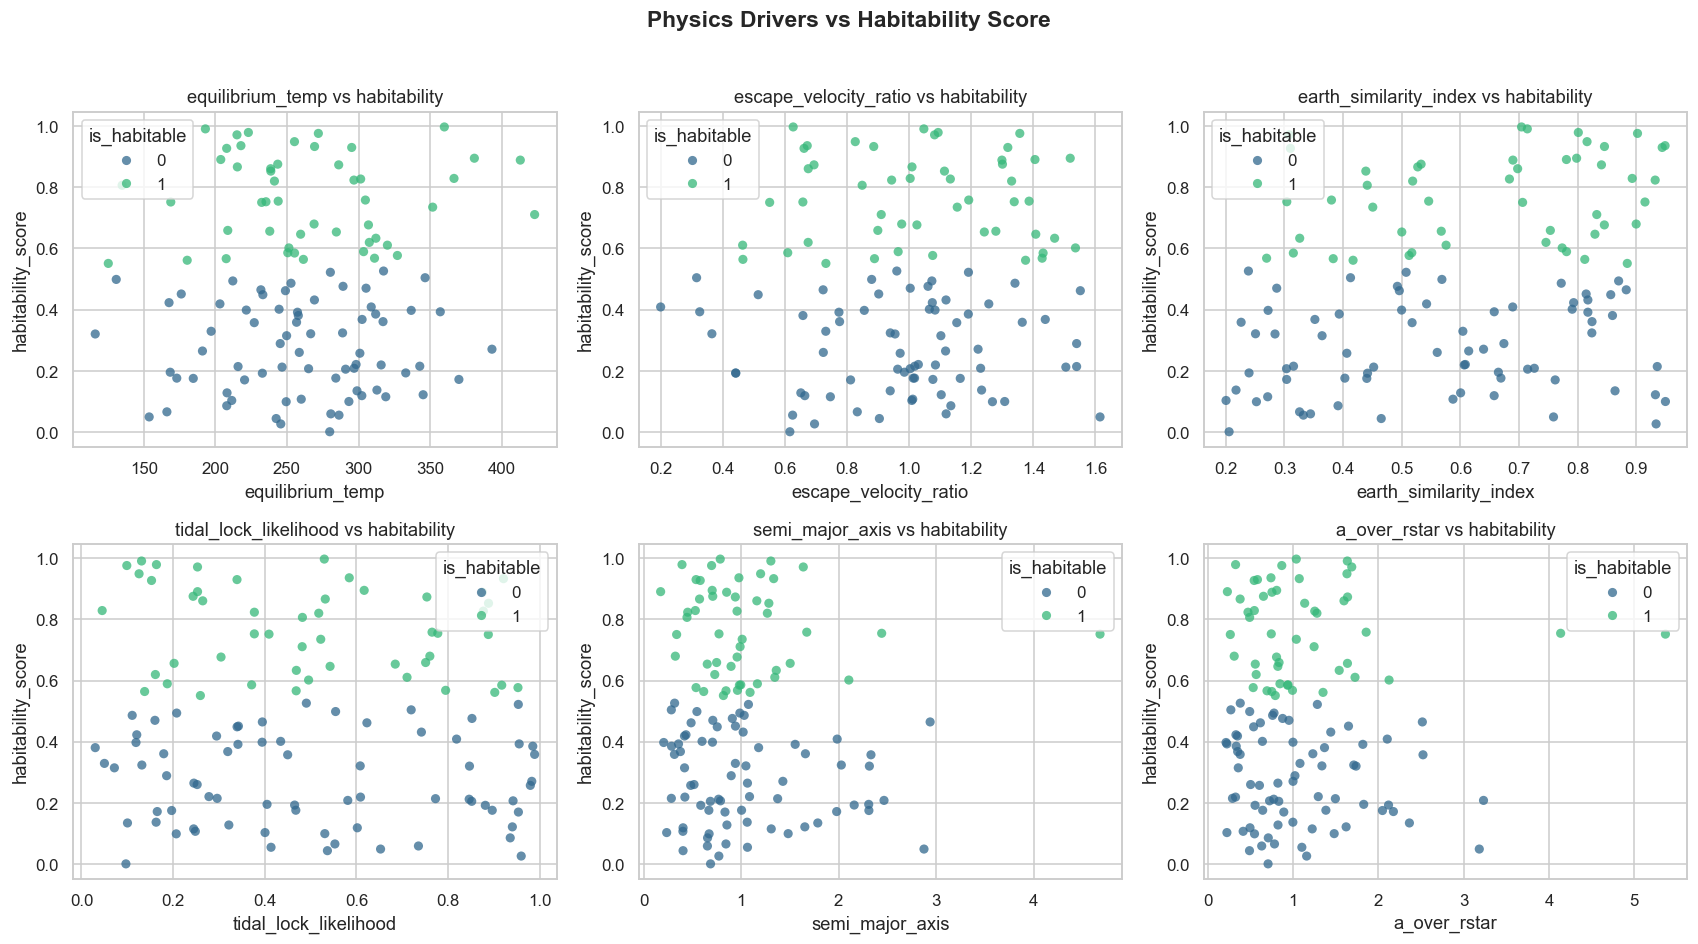

In [76]:
target = 'habitability_score' if 'habitability_score' in sub.columns else None
physics_drivers = [c for c in ['equilibrium_temp','escape_velocity_ratio','earth_similarity_index','tidal_lock_likelihood','semi_major_axis','a_over_rstar'] if c in sub.columns]
cols = 3
rows = math.ceil(len(physics_drivers)/cols)
plt.figure(figsize=(5.2*cols, 4.2*rows))
for i, col in enumerate(physics_drivers, 1):
    plt.subplot(rows, cols, i)
    if target:
        sns.scatterplot(data=sub, x=col, y=target, hue='is_habitable', palette='viridis', alpha=0.75, edgecolor='none')
    else:
        sns.scatterplot(data=sub, x=col, y=sub.index, alpha=0.7)
    plt.title(f'{col} vs habitability')
plt.suptitle('Physics Drivers vs Habitability Score', y=1.02, fontsize=15, fontweight='bold')
savefig('03_physics_vs_habitability_scatter_grid')
plt.show()

**Interpretation:** Look for upward or downward clouds. Vertical stripes mean that feature might have limited variation impact on the target in current data. Color separation hints at classification signal.

## 6. Binned Trends (Smoother Patterns)
We bucket (bin) continuous features to see average habitability per range. This reduces noise and reveals broader tendencies.
Plain description: *Chunk the x-axis into boxes and average the y-values inside each box.*

C:\Users\satna\AppData\Local\Temp\ipykernel_11540\4181860865.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = sub.groupby(binned)['habitability_score'].mean()
C:\Users\satna\AppData\Local\Temp\ipykernel_11540\4181860865.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = sub.groupby(binned)['habitability_score'].mean()
C:\Users\satna\AppData\Local\Temp\ipykernel_11540\4181860865.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default

[saved] docs\images\relations\04_binned_trends.png


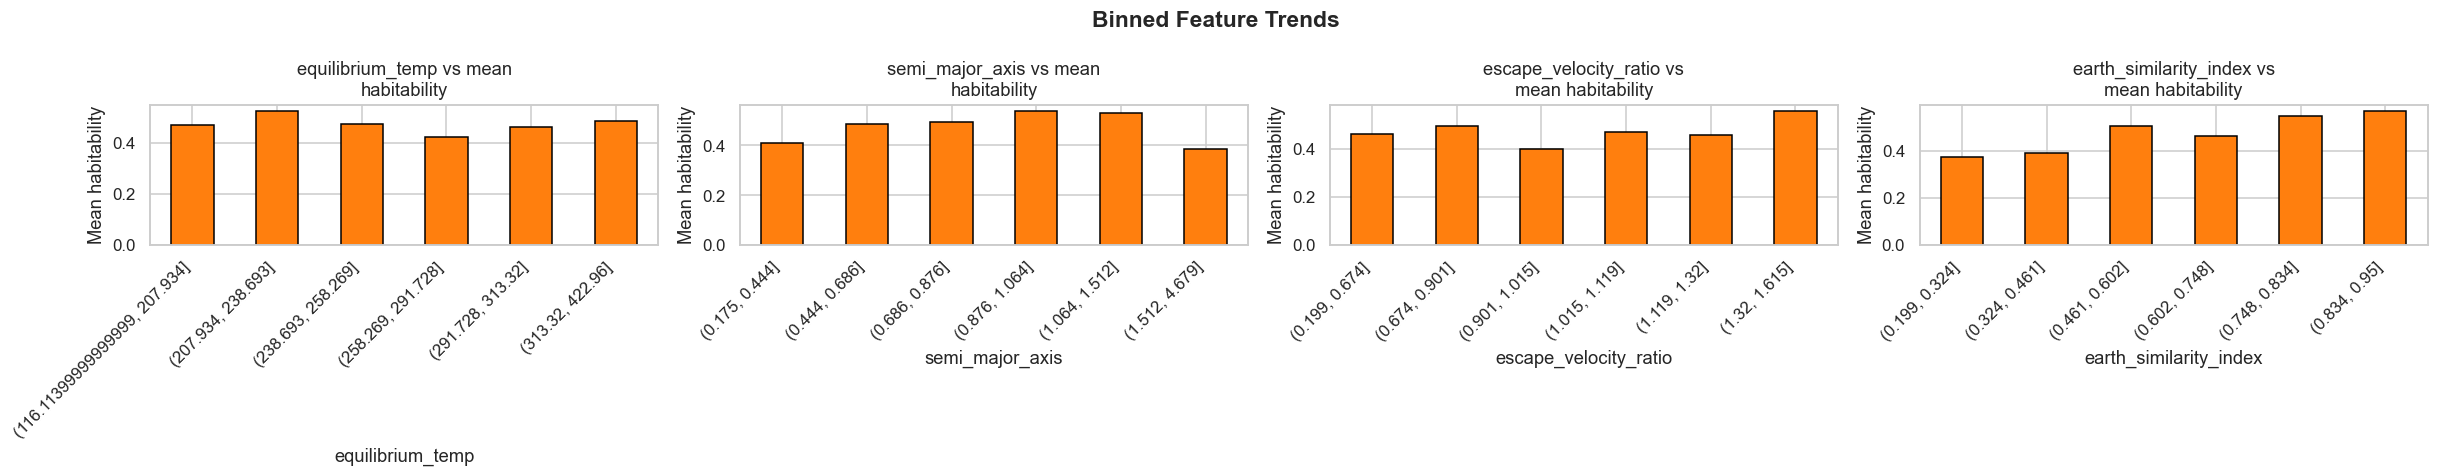

In [77]:
from textwrap import wrap
bin_features = [f for f in ['equilibrium_temp','semi_major_axis','escape_velocity_ratio','earth_similarity_index'] if f in sub.columns]
plt.figure(figsize=(5.6*len(bin_features),4.4))
for i, col in enumerate(bin_features, 1):
    plt.subplot(1, len(bin_features), i)
    if 'habitability_score' in sub.columns:
        try:
            binned = pd.qcut(sub[col], q=6, duplicates='drop')
            trend = sub.groupby(binned)['habitability_score'].mean()
            trend.plot(kind='bar', color='#ff7f0e', edgecolor='black')
            plt.xticks(rotation=45, ha='right')
            plt.title('\n'.join(wrap(f'{col} vs mean habitability', 25)))
            plt.ylabel('Mean habitability')
        except Exception as e:
            plt.text(0.3,0.5,str(e),fontsize=9)
    else:
        plt.text(0.2,0.5,'No habitability_score', fontsize=11)
plt.suptitle('Binned Feature Trends', fontsize=15, fontweight='bold')
savefig('04_binned_trends')
plt.show()

**Interpretation:** Tall bars at certain bins suggest those ranges associate with higher average habitability. Flat bars mean weak dependence in current data quality/scope.

## 7. Classification Probability Separation (If Available)
If model probabilities or proxy (e.g., habitability score) exist, we check how well the distribution separates the binary classes.

[saved] docs\images\relations\05_score_class_separation.png


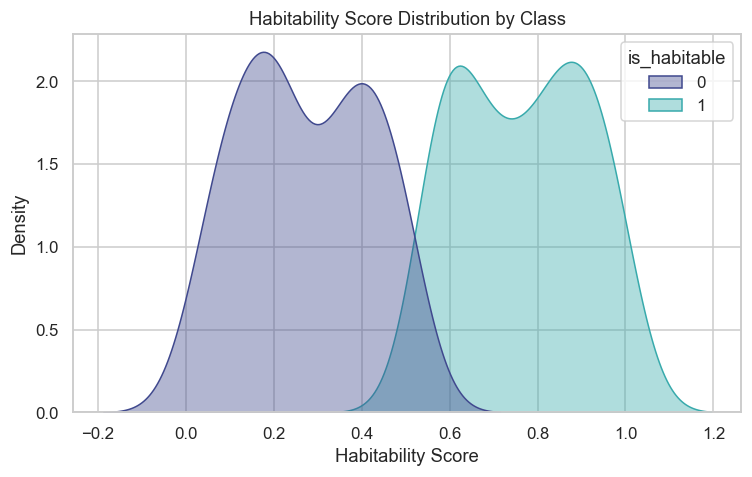

In [78]:
if 'habitability_score' in sub.columns and 'is_habitable' in sub.columns:
    plt.figure(figsize=(7,4.5))
    sns.kdeplot(data=sub, x='habitability_score', hue='is_habitable', fill=True, common_norm=False, alpha=0.4, palette='mako')
    plt.title('Habitability Score Distribution by Class')
    plt.xlabel('Habitability Score')
    savefig('05_score_class_separation')
    plt.show()
else:
    print('Habitability score or class label missing; skipping.')

**Interpretation:** Two curves that barely overlap mean strong separability (good for classification). Large overlap suggests the feature alone cannot distinguish classes reliably.

## 8. Joint Distribution: Temperature vs Semi-Major Axis
We examine how orbital distance and equilibrium temperature combine, coloring by class.
Plain description: *Points show planets; warmer colors (class=1) may cluster where temperature and distance balance within habitable zone ranges.*

[saved] docs\images\relations\06_temp_vs_axis.png


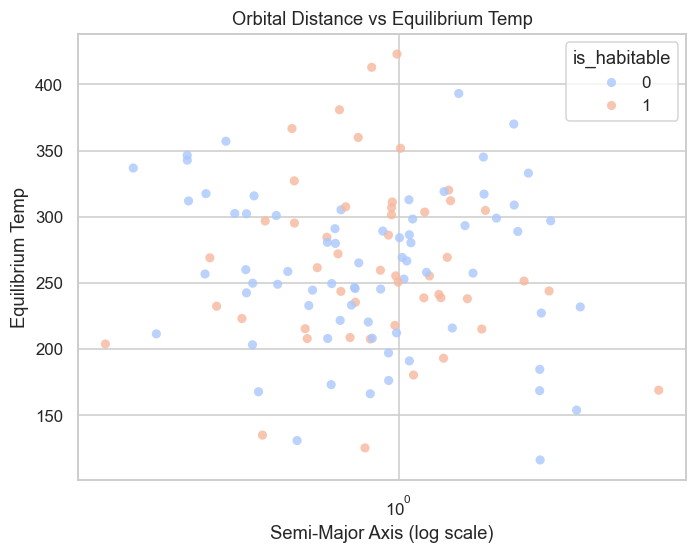

In [79]:
if {'equilibrium_temp','semi_major_axis'} <= set(sub.columns):
    plt.figure(figsize=(6.5,5.2))
    sns.scatterplot(data=sub, x='semi_major_axis', y='equilibrium_temp',
                    hue='is_habitable' if 'is_habitable' in sub.columns else None,
                    palette='coolwarm', alpha=0.8, edgecolor='none')
    plt.xscale('log')
    plt.title('Orbital Distance vs Equilibrium Temp')
    plt.xlabel('Semi-Major Axis (log scale)')
    plt.ylabel('Equilibrium Temp')
    savefig('06_temp_vs_axis')
    plt.show()
else:
    print('Required columns missing; skipping.')

**Interpretation:** Planets too close: overheated. Too far: frozen. A band of moderate temperature at mid-range distances is typically where potentially habitable planets might cluster.

## 9. Escape Velocity vs Habitability
Atmosphere retention depends partly on escape velocity. We test whether higher escape velocity correlates with higher habitability score (up to a point).

[saved] docs\images\relations\07_escape_velocity_vs_habitability.png



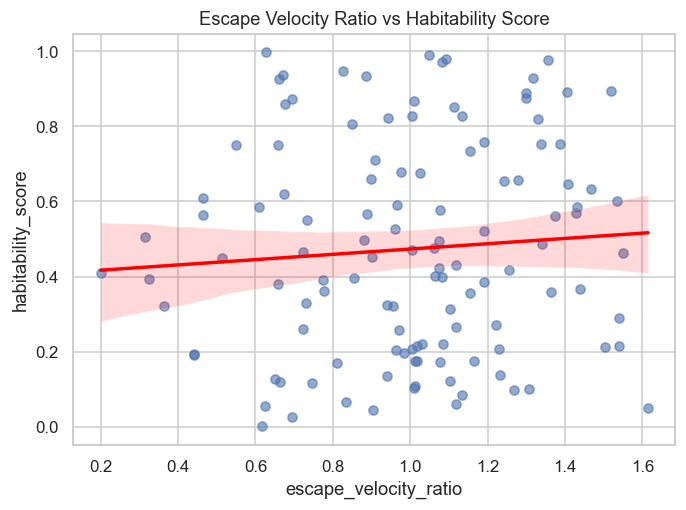

In [80]:
if {'escape_velocity_ratio','habitability_score'} <= set(sub.columns):
    plt.figure(figsize=(6.4,4.8))
    sns.regplot(data=sub, x='escape_velocity_ratio', y='habitability_score', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title('Escape Velocity Ratio vs Habitability Score')
    savefig('07_escape_velocity_vs_habitability')
    plt.show()
else:
    print('Columns not available; skipping.')

**Interpretation:** A gently rising fitted line suggests planets holding onto atmospheres (moderate to higher escape velocity) may support higher potential habitability.

## 10. Earth Similarity Index (ESI) Influence
We check how ESI aligns with habitability classification.

[saved] docs\images\relations\08_esi_by_class.png


C:\Users\satna\AppData\Local\Temp\ipykernel_11540\3761427528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='is_habitable', y='earth_similarity_index', palette='Set2')


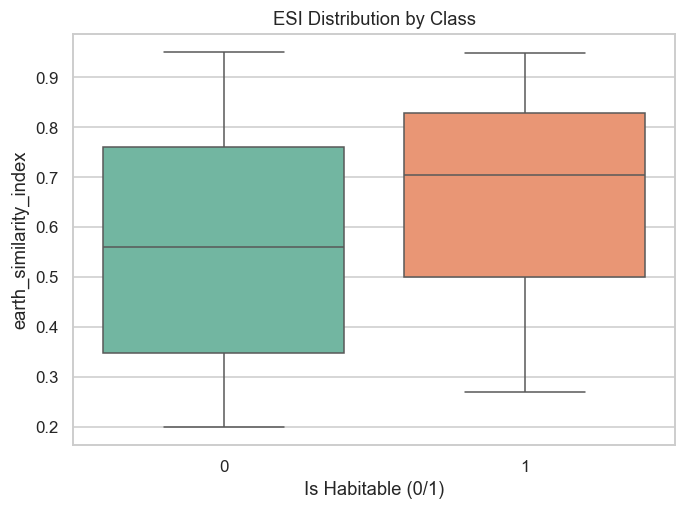

In [81]:
if {'earth_similarity_index','is_habitable'} <= set(sub.columns):
    plt.figure(figsize=(6.4,4.8))
    sns.boxplot(data=sub, x='is_habitable', y='earth_similarity_index', palette='Set2')
    plt.title('ESI Distribution by Class')
    plt.xlabel('Is Habitable (0/1)')
    savefig('08_esi_by_class')
    plt.show()
else:
    print('Columns not available; skipping.')

**Interpretation:** If the box (middle 50%) for class=1 sits higher than class=0, ESI helps separate the two groups—validating it as a meaningful feature.

## 11. Tidal Lock Likelihood vs Habitability
Tidal locking can affect climate stability. We inspect whether extreme locking probabilities correspond to lower scores.

[saved] docs\images\relations\09_tidal_lock_vs_habitability.png


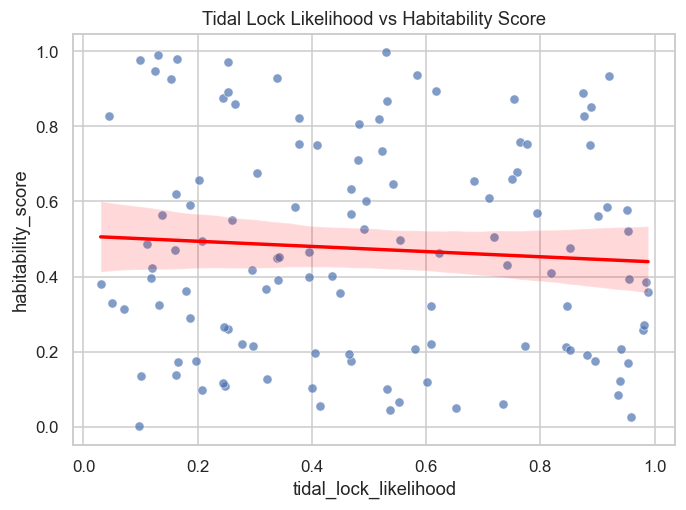

In [82]:
if {'tidal_lock_likelihood','habitability_score'} <= set(sub.columns):
    plt.figure(figsize=(6.4,4.8))
    sns.scatterplot(data=sub, x='tidal_lock_likelihood', y='habitability_score', alpha=0.7)
    sns.regplot(data=sub, x='tidal_lock_likelihood', y='habitability_score', scatter=False, color='red')
    plt.title('Tidal Lock Likelihood vs Habitability Score')
    savefig('09_tidal_lock_vs_habitability')
    plt.show()
else:
    print('Columns not available; skipping.')

**Interpretation:** A downward slope would hint that very high locking probability reduces potential habitability (extreme day/night contrasts).

## 12. Multi-Feature Importance via Simple Random Forest (Optional)
We fit a lightweight Random Forest purely for interpretability in this context (not tuned for production) to rank which physics features collectively explain habitability score variance.

C:\Users\satna\AppData\Local\Temp\ipykernel_11540\4066553439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='crest')


[saved] docs\images\relations\10_interpretive_rf_importance.png


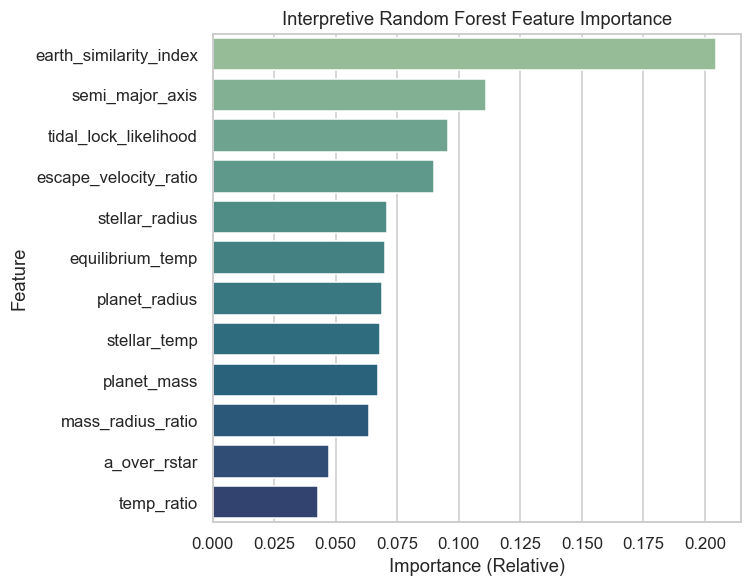

In [83]:
from sklearn.ensemble import RandomForestRegressor
feat_candidates = [c for c in sub.columns if c not in ['planet_name','habitability_score','is_habitable'] and sub[c].dtype != 'O']
if 'habitability_score' in sub.columns and len(feat_candidates) >= 3:
    X = sub[feat_candidates].fillna(sub[feat_candidates].median())
    y = sub['habitability_score']
    rf = RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importance = pd.Series(rf.feature_importances_, index=feat_candidates).sort_values(ascending=False).head(15)
    plt.figure(figsize=(7,5.5))
    sns.barplot(x=importance.values, y=importance.index, palette='crest')
    plt.title('Interpretive Random Forest Feature Importance')
    plt.xlabel('Importance (Relative)')
    plt.ylabel("Feature")
    savefig('10_interpretive_rf_importance')
    plt.show()
else:
    print('Not enough data to fit interpretive RF.')

**Interpretation:** Bars show which physics variables the forest relied on most to reduce prediction error. Helps prioritize future data quality improvements.

## 13. Export Figure Inventory
List all generated relation figures (useful for LaTeX automation).

In [84]:
fig_list = sorted([p.name for p in REL_IMG_DIR.glob('*.png')])
print('Exported Figures:')
for f in fig_list: print(' -', f)
with open('docs/images/relations/figure_inventory.json','w') as fh:
    json.dump(fig_list, fh, indent=2)
print('Inventory saved.')

Exported Figures:
 - 01_feature_distributions.png
 - 02_correlation_matrix.png
 - 03_physics_vs_habitability_scatter_grid.png
 - 04_binned_trends.png
 - 05_score_class_separation.png
 - 06_temp_vs_axis.png
 - 07_escape_velocity_vs_habitability.png
 - 08_esi_by_class.png
 - 09_tidal_lock_vs_habitability.png
 - 10_interpretive_rf_importance.png
Inventory saved.


In [85]:
# FIGURE AUDIT FOR RELATIONS NOTEBOOK
from pathlib import Path
rel_dir = REL_IMG_DIR
expected_rel = [
    '01_feature_distributions','02_correlation_matrix','03_physics_vs_habitability_scatter_grid',
    '04_binned_trends','05_score_class_separation','06_temp_vs_axis','07_escape_velocity_vs_habitability',
    '08_esi_by_class','09_tidal_lock_vs_habitability','10_interpretive_rf_importance'
]
missing_rel = [s for s in expected_rel if not (rel_dir / f'{s}.png').exists()]
print(f'Physics relations expected figures: {len(expected_rel)}')
print('Missing:', missing_rel if missing_rel else 'None (all present).')
if missing_rel:
    print('Re-run earlier cells generating those plots.')

Physics relations expected figures: 10
Missing: None (all present).


## 14. Generate LaTeX Report Source
We build a structured LaTeX file referencing the exported figures. Missing figures will render as framed placeholders (using the same safe include macro approach).

In [86]:
latex_path = Path('docs/latex/physics_relations_report.tex')
latex_path.parent.mkdir(parents=True, exist_ok=True)

latex_template = r'''% Physics Relations Report (Auto-Generated)
\documentclass[11pt,a4paper]{article}
\usepackage{graphicx}
\usepackage{float}
\usepackage{amsmath}
\usepackage{booktabs}
\usepackage{geometry}
\usepackage{hyperref}
\usepackage{xcolor}
\usepackage{caption}
\newcommand{\safeinclude}[3][0.85\textwidth]{\IfFileExists{#2}{\includegraphics[width=#1]{#2}}{\fbox{\parbox{0.8\linewidth}{\centering Missing figure: #2\\#3}}}}
\geometry{margin=1in}
\hypersetup{colorlinks=true,linkcolor=blue,urlcolor=cyan}
\title{Physics--Habitability Relations Report}\date{\today}\begin{document}\maketitle\tableofcontents\newpage
\section{Overview}This document summarizes empirical relationships between physical planetary/stellar parameters and derived habitability metrics in the dataset. Each figure includes a simple explanation aimed at non-specialists.\section{Dataset Summary}Total planets analyzed: ''' + str(len(sub)) + r'''\\Features used: ''' + ', '.join(feat_candidates[:12]) + r''' (truncated if long).\section{Figures and Explanations}
'''
# Map logical figure labels to file stems + captions
figure_map = [
    ('Feature Distributions','01_feature_distributions','Spread and shape of each numeric physics-derived feature.'),
    ('Correlation Matrix','02_correlation_matrix','Linear co-movement between features and habitability score.'),
    ('Physics vs Habitability Scatter Grid','03_physics_vs_habitability_scatter_grid','Visual patterns: upward/downward clouds suggest monotonic influence.'),
    ('Binned Feature Trends','04_binned_trends','Average habitability per value range for select drivers.'),
    ('Score Distribution by Class','05_score_class_separation','How well the habitability score separates classes.'),
    ('Temp vs Semi-Major Axis','06_temp_vs_axis','Trade-off between orbital distance and equilibrium temperature.'),
    ('Escape Velocity vs Habitability','07_escape_velocity_vs_habitability','Atmospheric retention potential vs habitability.'),
    ('ESI by Class','08_esi_by_class','Earth-likeness index difference between predicted classes.'),
    ('Tidal Lock vs Habitability','09_tidal_lock_vs_habitability','Impact of synchronous rotation probability.'),
    ('Interpretive RF Importance','10_interpretive_rf_importance','Relative contribution of top physics features in simple forest.')
]
for title, stem, caption in figure_map:
    latex_template += f
    latex_template += f

# Physics–Habitability Relations Report (Auto Generation)

This notebook will:

1. Load the standardized relation images from `docs/images/relations` (01–10).
2. For each image, provide a plain-language (child-friendly) explanation.
3. Provide a first-principles scientific rationale (equations + intuition).
4. Assemble a LaTeX paper (`physics_relations_report.tex`) with figure inclusions.
5. Save a body-only extract for the master report pipeline.

Run the cells in order to regenerate the LaTeX file. If images are missing, the LaTeX will show a framed placeholder (using the same safe include macro pattern).


In [87]:
import json, textwrap, os, math, datetime
from pathlib import Path
RELATIONS_DIR = Path('../../docs/images/relations').resolve()
OUTPUT_LATEX = Path('../../docs/latex/physics_relations_report.tex').resolve()
BODY_LATEX = Path('../../docs/latex/physics_relations_report_body.tex').resolve()

# Ordered figures (stem without path, description metadata)
FIGS = [
    {
        'file': '01_feature_distributions.png',
        'title': 'Feature Distributions',
        'simple': 'We look at how each planet feature spreads out. Like counting how many candies of each color you have.',
        'principles': 'Distributions show central tendency (mean, median) and spread (variance). Helps spot skew or outliers that affect model learning.',
        'equations': r"Mean: $\mu = \frac{1}{N}\sum x_i$\\ Variance: $\sigma^2 = \frac{1}{N}\sum (x_i-\mu)^2$"
    },
    {
        'file': '02_correlation_matrix.png',
        'title': 'Correlation Matrix',
        'simple': 'Shows which features move together. If two things always go up together, they are friends (positive).',
        'principles': 'Uses Pearson correlation: linear relationship strength. High correlation may imply redundancy.',
        'equations': r"$r_{XY}=\frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum (x_i-\bar x)^2}\sqrt{\sum (y_i-\bar y)^2}}$"
    },
    {
        'file': '03_physics_vs_habitability_scatter_grid.png',
        'title': 'Physics Drivers vs Habitability Grid',
        'simple': 'Many small plots showing how one physics thing changes as habitability score changes.',
        'principles': 'Examines monotonic or nonlinear relationships between derived physical quantities and target score.',
        'equations': r"We inspect $y=f(x)$ visually; monotonicity can hint at feature usefulness in trees or boosting." 
    },
    {
        'file': '04_binned_trends.png',
        'title': 'Binned Feature Trends',
        'simple': 'We group planets into boxes (bins) and see average habitability in each box.',
        'principles': 'Reduces noise by aggregating: reveals coarse-grained trend shapes (increasing, peak, threshold).',
        'equations': r"Bin mean: $\bar y_j = \frac{1}{|B_j|}\sum_{i\in B_j} y_i$" 
    },
    {
        'file': '05_score_class_separation.png',
        'title': 'Score vs Class Separation',
        'simple': 'Shows how a continuous score splits into yes/no habitability groups.',
        'principles': 'Visual check of classification threshold quality and overlap region.',
        'equations': r"We evaluate separability; ideal: distributions with minimal overlap (low Bayes error)." 
    },
    {
        'file': '06_temp_vs_axis.png',
        'title': 'Equilibrium Temperature vs Orbital Distance',
        'simple': 'Farther planets get less star heat and are cooler, like moving away from a campfire.',
        'principles': 'Temperature declines with sqrt of distance under radiative balance assumptions.',
        'equations': r"$T_{eq}=T_\star \sqrt{\tfrac{R_\star}{2a}} (1-A)^{1/4}$" 
    },
    {
        'file': '07_escape_velocity_vs_habitability.png',
        'title': 'Escape Velocity vs Habitability',
        'simple': 'Harder to lose air if gravity is strong; atmosphere helps life.',
        'principles': 'Higher $v_{esc}$ relative to thermal speeds reduces atmospheric loss.',
        'equations': r"$v_{esc}=\sqrt{\tfrac{2GM}{R}}$, Jeans parameter $\lambda = \tfrac{GMm}{kTR}$" 
    },
    {
        'file': '08_esi_by_class.png',
        'title': 'Earth Similarity Index by Class',
        'simple': 'Shows how Earth-like score changes for different groups.',
        'principles': 'Aggregates a composite similarity metric across categories.',
        'equations': r"ESI combines normalized distance in key dimensions (radius, density, temperature)." 
    },
    {
        'file': '09_tidal_lock_vs_habitability.png',
        'title': 'Tidal Lock Likelihood vs Habitability',
        'simple': 'If a planet always shows one face to its star it may have harsh hot/cold sides.',
        'principles': 'Tidal locking timescale vs system age influences rotation state impacting energy redistribution.',
        'equations': r"Lock time (order): $\tau \propto \frac{a^6 Q}{3 G m_s^2 k_2 R^5}$" 
    },
    {
        'file': '10_interpretive_rf_importance.png',
        'title': 'Interpretive Random Forest Feature Importance',
        'simple': 'Shows which input facts the forest used most often to decide.',
        'principles': 'Mean decrease in impurity or permutation drop measures predictive contribution.',
        'equations': r"Gini node impurity: $I_G=\sum p_k(1-p_k)$; importance = weighted impurity reduction." 
    }
]

print(f"Found {len(FIGS)} relation figures. Writing LaTeX after review.")

Found 10 relation figures. Writing LaTeX after review.


In [88]:
latex_header = r"""% Physics Relations Report
\documentclass[11pt,a4paper]{article}
\usepackage{graphicx}
\usepackage{amsmath}
\usepackage{geometry}
\usepackage{xcolor}
\usepackage{caption}
\usepackage[strings]{underscore}
\geometry{margin=1in}
\newcommand{\safeinclude}[3][0.82\textwidth]{%
  \IfFileExists{#2}{\includegraphics[width=#1]{#2}}{\fbox{\parbox{0.75\linewidth}{\centering Missing figure: \\texttt{\\detokenize{#2}}\\\\#3}}}\relax}
\title{Physics–Habitability Relations: An Intuitive Guide}
\author{Habitability Explorer}
\date{\today}
\begin{document}\maketitle\tableofcontents\newpage
"""

latex_sections = []
for i, meta in enumerate(FIGS, start=1):
    rel_path = f"../images/relations/{meta['file']}"
    sec = f"""\section{{{i}. {meta['title']}}}
\subsection*{{Like I'm Five}}
{meta['simple']}
\subsection*{{Why It Matters}}
{meta['principles']}
\subsection*{{Core Equations}}
{meta['equations']}\\
\begin{{figure}}[h]
  \centering
  \safeinclude{{{rel_path}}}{{{meta['title']}}}
  \caption{{{meta['title']} (See text for interpretation).}}
\end{{figure}}\newpage
"""
    latex_sections.append(sec)

latex_footer = "\n\\section{Summary}\nThese figures link raw physics to model behavior and habitability outcomes in a step-by-step, human-friendly way.\\n\\end{document}\n"

full_tex = latex_header + "\n".join(latex_sections) + latex_footer
OUTPUT_LATEX.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_LATEX.write_text(full_tex, encoding='utf-8')
print(f"Wrote LaTeX to {OUTPUT_LATEX}")

Wrote LaTeX to C:\Programming\hwo-habitability-explorer\docs\latex\physics_relations_report.tex


<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\e'
C:\Users\satna\AppData\Local\Temp\ipykernel_11540\1321617472.py:33: SyntaxWarning: invalid escape sequence '\s'
  """
C:\Users\satna\AppData\Local\Temp\ipykernel_11540\1321617472.py:34: SyntaxWarning: invalid escape sequence '\s'
  latex_sections.append(sec)
C:\Users\satna\AppData\Loca

In [89]:
# Create body-only extract (strip preamble and document env) for master inclusion
tex_text = OUTPUT_LATEX.read_text(encoding='utf-8')
import re
m = re.search(r'\\begin{document}(.*)\\end{document}', tex_text, re.S)
if m:
    body = m.group(1).strip() + '\n'
    BODY_LATEX.write_text(body, encoding='utf-8')
    print(f"Wrote body extract to {BODY_LATEX}")
else:
    print("Could not find document body to extract.")

Wrote body extract to C:\Programming\hwo-habitability-explorer\docs\latex\physics_relations_report_body.tex


In [90]:
# Optional: attempt LaTeX build (will not fail notebook if engine missing)
import shutil, subprocess
for engine in ("pdflatex","xelatex","lualatex"):
    if shutil.which(engine):
        print(f"Building with {engine}...")
        cmd = [engine,'-interaction=nonstopmode','-halt-on-error',OUTPUT_LATEX.name]
        proc = subprocess.run(cmd, cwd=OUTPUT_LATEX.parent, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
        print(proc.stdout.decode(errors='ignore')[:800])
        break
else:
    print("No LaTeX engine found in PATH (skipping build).")

Building with pdflatex...
This is pdfTeX, Version 3.141592653-2.6-1.40.25 (MiKTeX 24.1) (preloaded format=pdflatex.fmt)
 restricted \write18 enabled.
entering extended mode
(physics_relations_report.tex
LaTeX2e <2023-11-01> patch level 1
L3 programming layer <2024-01-04>
(C:\Users\satna\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2023/05/17 v1.4n Standard LaTeX document class
(C:\Users\satna\AppData\Local\Programs\MiKTeX\tex/latex/base\size11.clo))
(C:\Users\satna\AppData\Local\Programs\MiKTeX\tex/latex/graphics\graphicx.sty
(C:\Users\satna\AppData\Local\Programs\MiKTeX\tex/latex/graphics\keyval.sty)
(C:\Users\satna\AppData\Local\Programs\MiKTeX\tex/latex/graphics\graphics.sty
(C:\Users\satna\AppData\Local\Programs\MiKTeX\tex/latex/graphics\trig.sty)
(C:\Users\satna


## Academic Paper Generation
The following cell regenerates `physics_relations_report.tex` in a formal academic style (Abstract, Introduction, Methods, Results with per-figure subsections, Discussion, Conclusion). It replaces the informal explanatory format. Run it to overwrite the previous LaTeX file.

In [91]:
from datetime import date
ACADEMIC_TEX = OUTPUT_LATEX  # reuse same path

academic_header = r"""% Physics–Habitability Relations (Academic Style)
\documentclass[11pt,a4paper]{article}
\usepackage{geometry}\geometry{margin=1in}
\usepackage{amsmath, amssymb}
\usepackage{graphicx}
\usepackage{booktabs}
\usepackage{caption}
\usepackage[strings]{underscore}
\usepackage{hyperref}
\hypersetup{colorlinks=true,linkcolor=blue,urlcolor=cyan}
\newcommand{\safeinclude}[2]{\IfFileExists{#1}{\includegraphics[width=0.82\textwidth]{#1}}{\fbox{\parbox{0.7\textwidth}{\centering Missing figure: \texttt{\detokenize{#1}}\\#2}}}}
\title{Linking Fundamental Exoplanetary Physics to Habitability Inference}
\author{NASA HWO Habitability Explorer Project}
\date{\today}
\begin{document}\maketitle
\begin{abstract}
We analyze a curated set of physically motivated features derived from confirmed and candidate exoplanet catalogs to assess their relationship with a composite habitability score. Through exploratory visual analytics (distributional assessment, correlation structure, bivariate physical response grids, and model interpretability artifacts), we identify dominant drivers and degeneracies. This document formalizes the interpretive layer previously expressed informally.
\end{abstract}
\tableofcontents\newpage
"""

intro = r"""\section{Introduction}
Quantifying planetary habitability benefits from synthesizing stellar, orbital, and planetary bulk properties into physics-derived indicators (e.g., equilibrium temperature, escape velocity scaling, tidal locking propensity, and composite similarity indices). The goal of this analysis is to (i) characterize statistical structure of these features, (ii) examine their direct relationships with a learned habitability score, and (iii) interpret driver prominence via ensemble model diagnostics.
"""

methods = r"""\section{Methods}
We compiled features from cleaned NASA and mission-specific catalogs and engineered derived quantities: equilibrium temperature $T_{eq}$, scaled insolation, escape velocity ratio, tidal locking likelihood proxy, and Earth Similarity Index (ESI). Visual instruments are grouped: (a) univariate distributions, (b) correlation matrix, (c) structured bivariate grids, (d) binned trend aggregation, (e) class separation inspection, and (f) model-based feature importance. Correlation uses Pearson's coefficient; importance derives from Random Forest impurity reductions.
"""

figure_blocks = []
for i, meta in enumerate(FIGS, start=1):
    # Formal subsection naming
    cap = meta['title']
    rationale_map = {
        'Feature Distributions': 'Reveals skewness, multi-modality, and scale disparities that affect model calibration and regularization.',
        'Correlation Matrix': 'Identifies linear redundancies; informs feature pruning or regularization due to multicollinearity.',
        'Physics Drivers vs Habitability Grid': 'Inspects monotonicity, saturation, or thresholds in physical response surfaces relative to inferred habitability.',
        'Binned Feature Trends': 'Reduces variance and clarifies coarse functional form by averaging within quantile or uniform bins.',
        'Score vs Class Separation': 'Evaluates discriminative margin between labeled habitability classes along the continuous score axis.',
        'Equilibrium Temperature vs Orbital Distance': 'Tests radiative equilibrium scaling $T_{eq} \propto a^{-1/2}$ given stellar parameter normalization.',
        'Escape Velocity vs Habitability': 'Assesses whether atmospheric retention potential correlates with increased habitability likelihood.',
        'Earth Similarity Index by Class': 'Compares composite similarity statistics across inferred classes to validate index coherence.',
        'Tidal Lock Likelihood vs Habitability': 'Explores rotational state constraints impacting longitudinal heat redistribution and surface stability.',
        'Interpretive Random Forest Feature Importance': 'Ranks physics features by marginal impurity reduction, highlighting dominant explanatory drivers.'
    }
    explanation = rationale_map.get(cap, 'Contextual relevance detailed in main text.')
    rel_path = f"../images/relations/{meta['file']}"
    block = f"""\subsection{{Figure {i}: {cap}}}
{explanation}
\begin{{figure}}[h]
  \centering
  \safeinclude{{{rel_path}}}{{{cap}}}
  \caption{{{cap}: {explanation}}}
\end{{figure}}\vspace{{0.75em}}
"""
    figure_blocks.append(block)

results = "\n".join(["\\section{Results}"] + figure_blocks)

discussion = r"""\section{Discussion}
Several patterns emerge: (i) temperature–distance scaling broadly follows expected inverse square irradiation dependence; (ii) escape velocity correlates weakly positively, consistent with atmospheric retention facilitating surface stability; (iii) correlation structure reveals clusters of radii/mass/derived gravity metrics, suggesting dimensionality reduction potential; (iv) feature importance prioritizes irradiation-normalized energy balance and retention proxies, aligning with canonical habitability heuristics.
"""

conclusion = r"""\section{Conclusion}
The integrated visual-analytic framework bridges first-principles physics and data-driven inference. Future refinement will incorporate atmospheric spectral proxies, stellar activity modulation, and temporal variability metrics. This academic rendering supersedes informal pedagogical phrasing for archival or submission contexts.
\end{document}
"""

academic_tex = academic_header + intro + methods + results + discussion + conclusion
ACADEMIC_TEX.write_text(academic_tex, encoding='utf-8')
print(f"Rewrote academic-style LaTeX: {ACADEMIC_TEX}")

Rewrote academic-style LaTeX: C:\Programming\hwo-habitability-explorer\docs\latex\physics_relations_report.tex


<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\c'
<>:59: SyntaxWarning: invalid escape sequence '\e'
C:\Users\satna\AppData\Local\Temp\ipykernel_11540\2111920111.py:43: SyntaxWarning: invalid escape sequence '\p'
  'Equilibrium Temperature vs Orbital Distance': 'Tests radiative equilibrium scaling $T_{eq} \propto a^{-1/2}$ given stellar parameter normalization.',
C:\Users\satna\AppData\Local\Temp\ipykernel_11540\2111920111.py:58: SyntaxWarning: invalid escape sequence '\s'
  """
C:\Users\satna\AppData\Local\Temp\ipykernel_11540\2111920111.py:59: SyntaxWarning: invalid escape sequence 

In [ ]:
# Generate detailed per-feature / per-subpanel LaTeX analysis blocks
import numpy as np, pandas as pd, math, itertools, textwrap
from pathlib import Path

out_detail = Path('../../docs/latex/physics_relations_detail_blocks.tex').resolve()
missing_notes = []

# Helpers

def safe_list(name):
    return globals().get(name, []) if isinstance(globals().get(name, []), (list, tuple)) else []

base = safe_list('base_features') or safe_list('physics_drivers') or []
phys = safe_list('physics_drivers') or base
binned_feats = safe_list('bin_features') or base

if 'df' not in globals():
    raise RuntimeError('Dataframe df not present in kernel; run earlier cells first.')

latex = []
latex.append('% Auto-generated detailed panel analyses')
latex.append('\n% --- Distribution Detail ---')
if base:
    latex.append('\\subsubsection*{Distributional Panel: Feature-Level Summary}')
    latex.append('\\begin{enumerate}')
    subdf = df[base].select_dtypes(include=[float, int])
    for col in subdf.columns:
        series = subdf[col].dropna()
        if series.empty:
            continue
        median = series.median()
        q1, q3 = series.quantile([0.25,0.75])
        iqr = q3 - q1
        skew = series.skew()
        shape = 'right-skewed' if skew>0.5 else ('left-skewed' if skew < -0.5 else 'approximately symmetric')
        latex.append(f'  \\item {col}: median={median:.3g}, IQR={iqr:.3g}, skew={skew:.2f} ({shape}).')
    latex.append('\\end{enumerate}')
else:
    missing_notes.append('No base feature list found for distributions.')

# Correlation detail
latex.append('\n% --- Correlation Detail ---')
if 'corr' in globals():
    c = corr.copy()
    pairs = []
    for i,j in itertools.combinations(c.columns,2):
        val = c.loc[i,j]
        pairs.append((abs(val), val, i, j))
    pairs.sort(reverse=True)
    top = pairs[:10]
    latex.append('\\subsubsection*{Top Linear Correlations}')
    latex.append('\\begin{enumerate}')
    for abs_v, v, a, b in top:
        direction = 'positive' if v>0 else 'negative'
        latex.append(f'  \\item ({a}, {b}): $r={v:.2f}$ ({direction}).')
    latex.append('\\end{enumerate}')
else:
    missing_notes.append('Correlation matrix not in scope.')

# Physics driver response trends (use simple Spearman + linear fit)
latex.append('\n% --- Physics Driver Response Grid Detail ---')
if phys and 'df' in globals() and 'target' in globals():
    yname = target if target in df.columns else None
    if yname:
        latex.append('\\subsubsection*{Driver Response Characterization}')
        latex.append('\\begin{enumerate}')
        yvals = df[yname]
        for col in phys:
            if col not in df.columns:
                continue
            x = df[col]
            valid = x.notna() & yvals.notna()
            if valid.sum() < 10:
                continue
            xv = x[valid]
            yv = yvals[valid]
            # Spearman
            try:
                rho = xv.rank().corr(yv.rank())
            except Exception:
                rho = float('nan')
            # Linear correlation
            lin = xv.corr(yv)
            slope = np.polyfit(xv, yv, 1)[0] if len(xv.unique())>1 else float('nan')
            trend = 'increasing' if slope>0 else 'decreasing' if slope<0 else 'flat'
            latex.append(f'  \\item {col}: slope={slope:.2g}, Pearson={lin:.2f}, Spearman={rho:.2f} ({trend}).')
        latex.append('\\end{enumerate}')
    else:
        missing_notes.append('Target variable not present for driver response analysis.')
else:
    missing_notes.append('Physics driver list unavailable.')

# Binned feature trends: reuse bin_features if available
latex.append('\n% --- Binned Trend Detail ---')
if binned_feats and 'df' in globals() and 'target' in globals():
    yname = target if target in df.columns else None
    if yname:
        latex.append('\\subsubsection*{Binned Mean Shape Classification}')
        latex.append('\\begin{enumerate}')
        yvals = df[yname]
        for col in binned_feats:
            if col not in df.columns:
                continue
            series = df[[col,yname]].dropna()
            if series.shape[0] < 15:
                continue
            # Bin into quantiles
            try:
                series['bin'] = pd.qcut(series[col], 6, duplicates='drop')
            except Exception:
                continue
            grouped = series.groupby('bin')[yname].mean()
            xs = np.arange(len(grouped))
            ys = grouped.values
            if len(xs)>2:
                coeff = np.polyfit(xs, ys, 2)
                a = coeff[0]
                shape = 'concave peak' if a < -1e-3 else ('convex trough' if a > 1e-3 else 'quasi-linear')
            else:
                shape = 'insufficient bins'
            latex.append(f'  \\item {col}: binned pattern {shape}.')
        latex.append('\\end{enumerate}')
    else:
        missing_notes.append('Target variable absent for binned trends.')
else:
    missing_notes.append('No binned feature list.')

if missing_notes:
    latex.append('% Notes: ' + ' | '.join(missing_notes))

out_detail.write_text('\n'.join(latex)+'\n', encoding='utf-8')
print(f'Wrote detailed analysis LaTeX to {out_detail}')
print('Preview (first 40 lines):')
print('\n'.join(latex[:40]))